In [1]:
import csv
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/nue_properties.csv")

In [3]:
from scipy.stats import norm
from scipy import stats

# Example: column named 'values'
start_dir_x = df['start_dir_x']
start_dir_y = df['start_dir_y']
start_dir_z = df['start_dir_z']
ke = df['ke']

# Fit a normal distribution
mu_x, sigma_x = norm.fit(start_dir_x)
mu_y, sigma_y = norm.fit(start_dir_y)
mu_z, sigma_z = norm.fit(start_dir_z)

print(f"Mean (μ) X: {mu_x}")
print(f"Standard deviation (σ) X: {sigma_x}")

print(f"Mean (μ) y: {mu_y}")
print(f"Standard deviation (σ) y: {sigma_y}")

print(f"Mean (μ) z: {mu_z}")
print(f"Standard deviation (σ) z: {sigma_z}")

start_dir_x_below1GeV = start_dir_x[ke < 2000]
start_dir_y_below1GeV = start_dir_y[ke < 2000]
start_dir_z_below1GeV = start_dir_z[ke < 2000]
ke_below1GeV = ke[ke < 2000]

start_dir_x_above1GeV = start_dir_x[ke >= 2000]
start_dir_y_above1GeV = start_dir_y[ke >= 2000]
start_dir_z_above1GeV = start_dir_z[ke >= 2000]
ke_above1GeV = ke[ke >= 2000]

Mean (μ) X: -0.0008531345831568165
Standard deviation (σ) X: 0.28406547002277405
Mean (μ) y: -0.09901535089548963
Standard deviation (σ) y: 0.2790018194801542
Mean (μ) z: 0.8741286785051804
Standard deviation (σ) z: 0.259921295832552


Sample from fitted Generalized Half-Normal distribution: [-0.79284419]


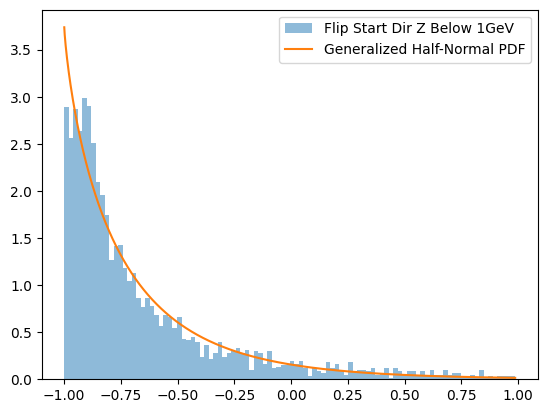

In [4]:
flip_start_dir_z_below1GeV = -start_dir_z_below1GeV
#beta_params = stats.beta.fit(start_dir_z)
expon_params = stats.halfgennorm.fit(flip_start_dir_z_below1GeV)

# Create x values
x = np.linspace(flip_start_dir_z_below1GeV.min(), flip_start_dir_z_below1GeV.max(), 1000)

# Evaluate PDF
pdf = stats.halfgennorm.pdf(x, *expon_params)

samples = stats.halfgennorm.rvs(*expon_params, size=1)
print(f"Sample from fitted Generalized Half-Normal distribution: {samples}")


import matplotlib.pyplot as plt

plt.hist(flip_start_dir_z_below1GeV, bins=100, density=True, alpha=0.5, label='Flip Start Dir Z Below 1GeV')
plt.plot(x, pdf, label='Generalized Half-Normal PDF')
#plt.ylim(0, 100)
plt.legend()
plt.show()

Sample from fitted Pareto distribution: [-0.99207276]


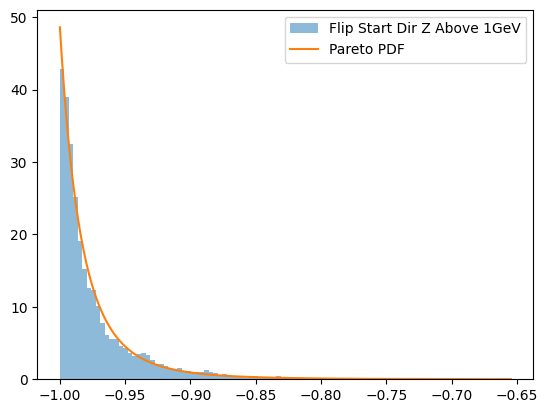

In [5]:
flip_start_dir_z_above1GeV = -start_dir_z_above1GeV
#beta_params = stats.beta.fit(start_dir_z)
pareto_params = stats.pareto.fit(flip_start_dir_z_above1GeV)

# Create x values
x = np.linspace(flip_start_dir_z_above1GeV.min(), flip_start_dir_z_above1GeV.max(), 1000)

# Evaluate PDF
pdf = stats.pareto.pdf(x, *pareto_params)

samples = stats.pareto.rvs(*pareto_params, size=1)
print(f"Sample from fitted Pareto distribution: {samples}")


import matplotlib.pyplot as plt

plt.hist(flip_start_dir_z_above1GeV, bins=100, density=True, alpha=0.5, label='Flip Start Dir Z Above 1GeV')
plt.plot(x, pdf, label='Pareto PDF')
#plt.ylim(0, 100)
plt.legend()
plt.show()

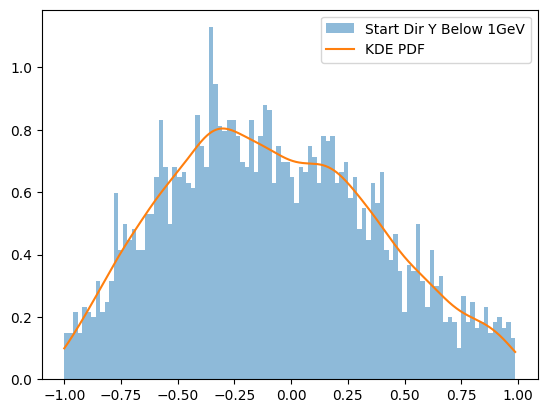

In [6]:
kde = stats.gaussian_kde(start_dir_y_below1GeV)

# Create x values
x = np.linspace(start_dir_y_below1GeV.min(), start_dir_y_below1GeV.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_y_below1GeV, bins=100, density=True, alpha=0.5, label='Start Dir Y Below 1GeV')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

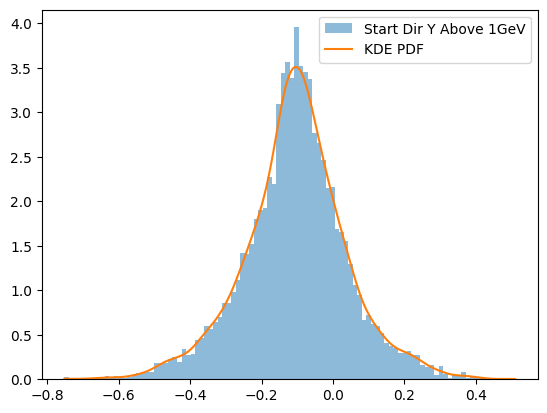

In [7]:
kde = stats.gaussian_kde(start_dir_y_above1GeV)

# Create x values
x = np.linspace(start_dir_y_above1GeV.min(), start_dir_y_above1GeV.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_y_above1GeV, bins=100, density=True, alpha=0.5, label='Start Dir Y Above 1GeV')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

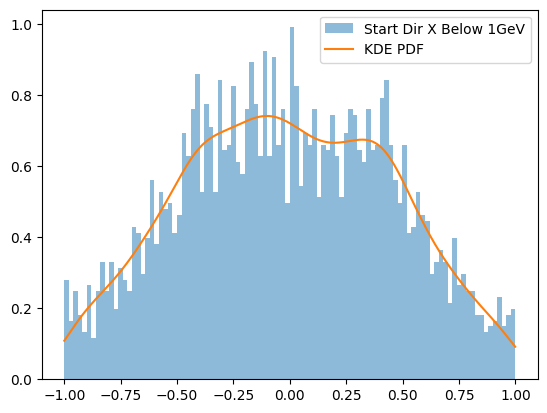

In [8]:
kde = stats.gaussian_kde(start_dir_x_below1GeV)
# Create x values
x = np.linspace(start_dir_x_below1GeV.min(), start_dir_x_below1GeV.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_x_below1GeV, bins=100, density=True, alpha=0.5, label='Start Dir X Below 1GeV')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

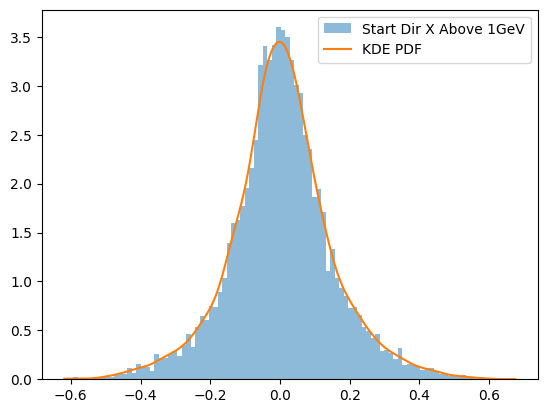

In [9]:
kde = stats.gaussian_kde(start_dir_x_above1GeV)
# Create x values
x = np.linspace(start_dir_x_above1GeV.min(), start_dir_x_above1GeV.max(), 1000)

# Evaluate PDF
pdf = kde(x)

import matplotlib.pyplot as plt

plt.hist(start_dir_x_above1GeV, bins=100, density=True, alpha=0.5, label='Start Dir X Above 1GeV')
plt.plot(x, pdf, label='KDE PDF')
plt.legend()
plt.show()

Percentage of events below 1 GeV: 97.46%


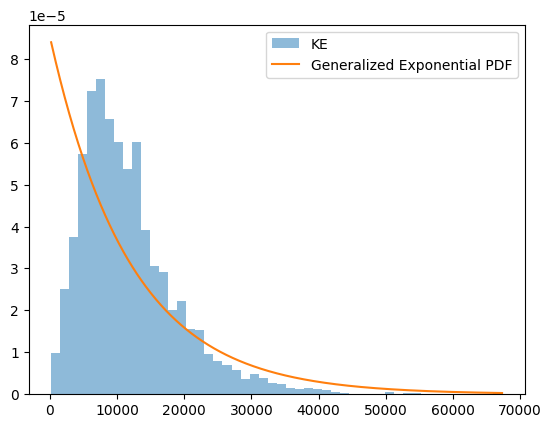

3910.134207087759


In [32]:
print("Percentage of events below 1 GeV: {:.2f}%".format(100 * len(ke_below1GeV) / len(ke)))
genexpon_params = stats.genexpon.fit(ke)

# Create x values
x = np.linspace(ke.min(), ke.max(), 1000)

# Evaluate PDF
pdf = stats.genexpon.pdf(x, *genexpon_params)

import matplotlib.pyplot as plt

plt.hist(ke, bins=50, density=True, alpha=0.5, label='KE')
plt.plot(x, pdf, label='Generalized Exponential PDF')
plt.legend()
plt.show()
print(np.median(df['ke']))

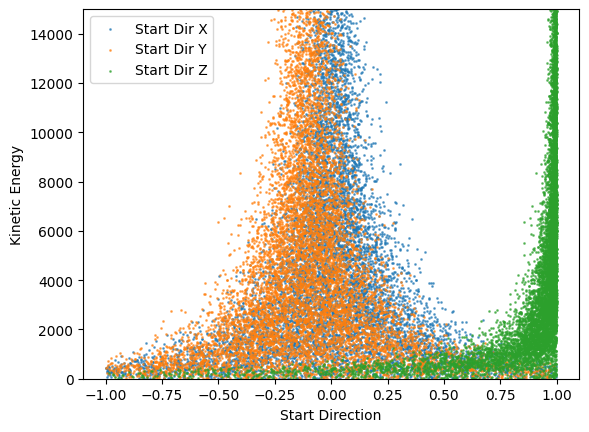

In [25]:
plt.scatter(start_dir_x, ke, label="Start Dir X", marker='o', s=1, alpha=0.6)
plt.scatter(start_dir_y, ke, label="Start Dir Y", marker='o', s=1, alpha=0.6)
plt.scatter(start_dir_z, ke, label="Start Dir Z", marker='o', s=1, alpha=0.6)
plt.ylabel("Kinetic Energy")
plt.xlabel("Start Direction")
plt.ylim(0, 15000)
plt.legend()
plt.show()

Beam dirs: [[ 0.    -0.101  0.995]
 [ 0.    -0.101  0.995]
 [ 0.    -0.101  0.995]
 ...
 [ 0.    -0.101  0.995]
 [ 0.    -0.101  0.995]
 [ 0.    -0.101  0.995]]
Shower dirs: [[ 0.1339108  -0.16443656  0.97725558]
 [ 0.03300586 -0.22298712  0.97426242]
 [-0.49992892 -0.15577811  0.85194147]
 ...
 [ 0.26980317 -0.46597621  0.84265792]
 [-0.15015908 -0.36057773  0.9205628 ]
 [ 0.06234457 -0.08239528  0.99464774]]
Shower dirs normalized: [0.99999998 0.99999995 1.         ... 0.99999998 0.99999996 0.99999998]
0.9889773978441954
0.9889773978441954


/tmp/ipykernel_1799924/3568935773.py:13: RuntimeWarning: invalid value encountered in arccos
  plt.hist(np.arccos(beam_dot_showers), bins=100, density=False, alpha=0.5, label='Beam Dot Showers')


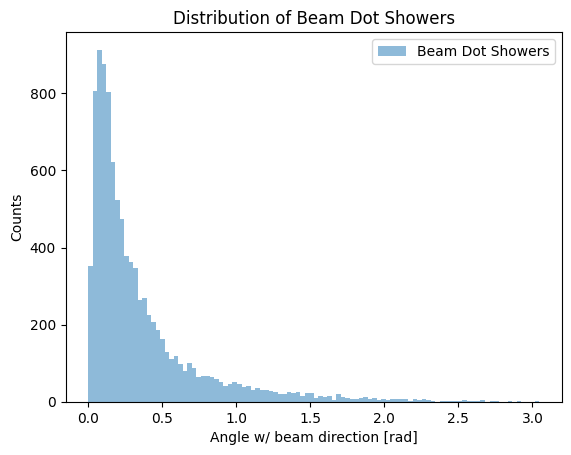

In [28]:
beam_dir = np.array([0, -0.101, 0.995])

shower_dirs = np.vstack((start_dir_x, start_dir_y, start_dir_z)).T
beam_dirs = np.tile(beam_dir, (shower_dirs.shape[0], 1))
print("Beam dirs:", beam_dirs)
print("Shower dirs:", shower_dirs)
print("Shower dirs normalized:", np.linalg.norm(shower_dirs, axis=1))

beam_dot_showers = np.array([np.dot(i, beam_dir) for i in shower_dirs])
print(beam_dot_showers[0])
print(shower_dirs[0,0]*beam_dir[0] + shower_dirs[0,1]*beam_dir[1] + shower_dirs[0,2]*beam_dir[2])

plt.hist(np.arccos(beam_dot_showers), bins=100, density=False, alpha=0.5, label='Beam Dot Showers')
plt.xlabel('Angle w/ beam direction [rad]')
plt.ylabel('Counts')
plt.title('Distribution of Beam Dot Showers')
plt.legend()
#plt.yscale('log')
plt.show()


/tmp/ipykernel_1799924/4283998706.py:1: RuntimeWarning: invalid value encountered in arccos
  angles = np.arccos(beam_dot_showers)
/tmp/ipykernel_1799924/4283998706.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


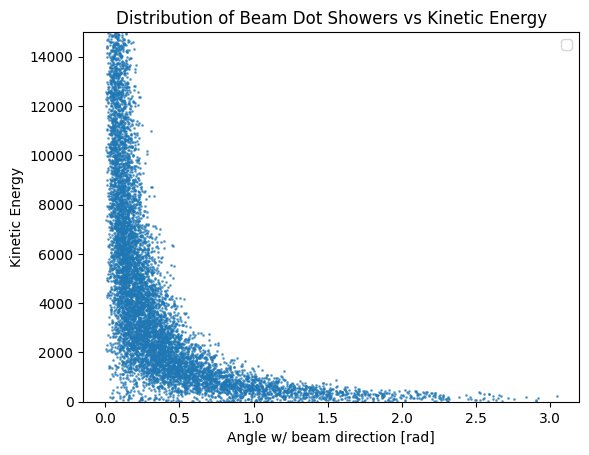

In [29]:
angles = np.arccos(beam_dot_showers)

plt.scatter(angles, ke, marker='o', s=1, alpha=0.6)
plt.xlabel('Angle w/ beam direction [rad]')
plt.ylabel('Kinetic Energy')
plt.ylim(0, 15000)
plt.title('Distribution of Beam Dot Showers vs Kinetic Energy')
plt.legend()
plt.show()

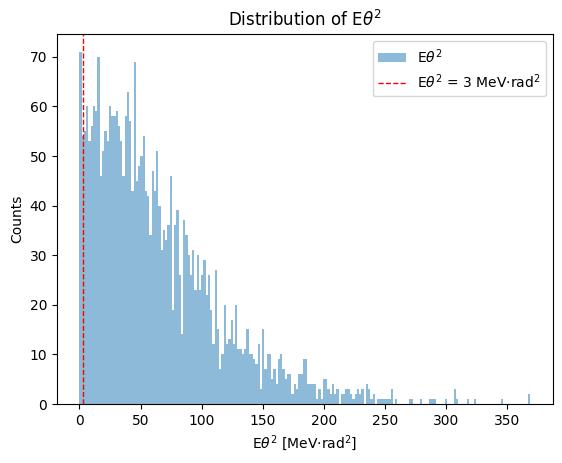

In [ ]:
angle_mask= angles < 0.13
angles = angles[angle_mask]
ke = ke[angle_mask]
ke_mask = ke > 150
angles = angles[ke_mask]
ke = ke[ke_mask]

ethetasq = (angles**2)*(ke+0.511)
plt.hist(ethetasq, bins=200, density=False, alpha=0.5, label=f'E$\\theta^2$')
plt.axvline(3, color='r', linestyle='dashed', linewidth=1, label=f'E$\\theta^2$ = 3 MeV$\cdot$rad$^2$')
plt.xlabel(f'E$\\theta^2$ [MeV$\cdot$rad$^2$]')
plt.ylabel('Counts')
plt.title('Distribution of E$\\theta^2$')
plt.legend()
plt.show()

